# import all frameworks


In [1]:
import pandas as pd
import numpy as np



## Load Dataset


In [2]:
df=pd.read_csv(r"C:\Users\abdul\Documents\BIA\ML\Dataset\Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


# Preprocessing
## 1.EDA

In [3]:
print("shape",df.shape)

shape (545, 13)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [5]:
df.describe(include='O')

C:\Users\abdul\AppData\Local\Temp\ipykernel_7644\2537740217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O')


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


## MIssing Value

In [6]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Catgorical vs Numerical cols

In [7]:
TARGET="price"

In [8]:
cat_cols=df.select_dtypes(include="str").columns.tolist()
print(cat_cols)

['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [9]:
cat_cols=df.select_dtypes(include="str").columns.tolist()
num_cols=df.select_dtypes(include=np.number).columns.drop(TARGET).tolist()
print("Categorical:",cat_cols)
print("Numerical:",num_cols)
#streamlit

Categorical: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Numerical: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


### Linear regression

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model


In [11]:
df=pd.read_csv(r"C:\Users\abdul\Documents\BIA\ML\Dataset\area.csv")
df

,area,price
0,1000.0,30000
1,1500.0,35000
2,NaN,40000
3,2500.0,45000
4,3000.0,50000
5,3500.0,55000
6,4000.0,60000
7,4500.0,65000
8,5000.0,70000


In [12]:
%matplotlib
plt.scatter(df.area,df.price)

Using matplotlib backend: module://matplotlib_inline.backend_inline


AttributeError: 'DataFrame' object has no attribute 'area'

In [13]:
print(df.columns)


Index(['area ', 'price '], dtype='str')


In [14]:
df.columns = df.columns.str.strip()

Using matplotlib backend: module://matplotlib_inline.backend_inline


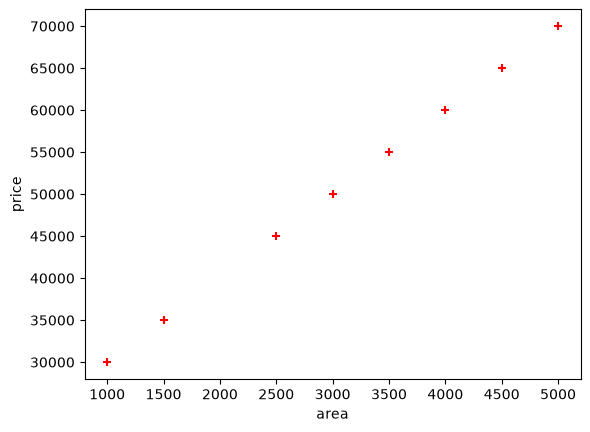

In [15]:
%matplotlib
plt.xlabel("area")
plt.ylabel("price")
plt.scatter(df.area,df.price,color="red",marker="+")

In [16]:
print(df[['area', 'price']].isnull().sum())

area     1
price    0
dtype: int64


In [17]:
df = df.dropna(subset=['area', 'price'])

In [18]:
reg=linear_model.LinearRegression()
reg.fit(df[['area']],df.price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [19]:
reg.predict([[1350]])

c:\Users\abdul\Documents\BIA\bia_py_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([33500.])

In [20]:
print("Coefficient:", reg.coef_[0])
print("Intercept:", reg.intercept_)

Coefficient: 10.0
Intercept: 20000.0


In [21]:
print(df.columns)

Index(['area', 'price'], dtype='str')


In [ ]:
df.columns = df.columns.str.strip()

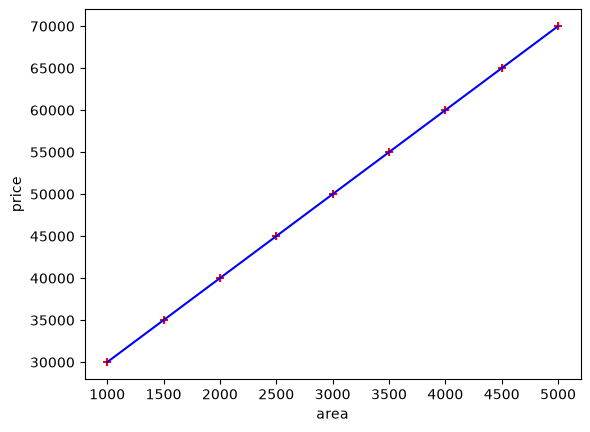

In [ ]:
%matplotlib inline
plt.xlabel("area")
plt.ylabel("price")
plt.scatter(df.area, df.price, color="red", marker="+")
plt.plot(df.area, reg.predict(df[['area']]), color="blue")
plt.show()

In [ ]:
print(df.columns)


Index(['area', 'price'], dtype='str')


In [ ]:
reg=linear_model.LinearRegression()
reg.fit(df[['area']],df.price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
reg.predict([[1775]])

c:\Users\abdul\Documents\BIA\bia_py_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([37750.])

In [ ]:
df.area

0    1000.0
1    1500.0
3    2500.0
4    3000.0
5    3500.0
6    4000.0
7    4500.0
8    5000.0
Name: area, dtype: float64

In [ ]:
df.index

Index([0, 1, 3, 4, 5, 6, 7, 8], dtype='int64')

In [ ]:
df.area=[1000,1500,2000,3000,3500,4000,4500,4700]

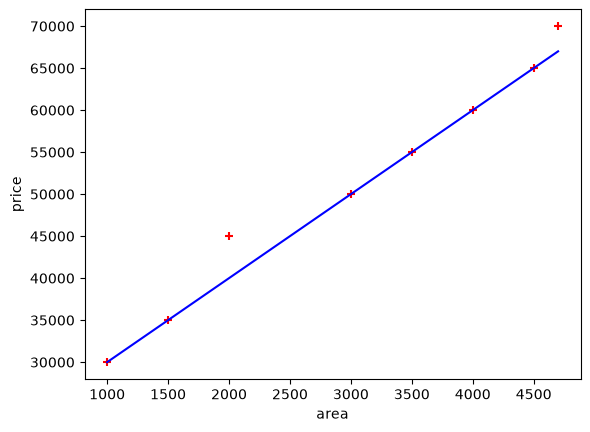

In [ ]:
%matplotlib inline
plt.xlabel("area")
plt.ylabel("price")
plt.scatter(df.area, df.price, color="red", marker="+")
plt.plot(df.area, reg.predict(df[['area']]), color="blue")
plt.show()

In [ ]:
reg=linear_model.LinearRegression()
reg.fit(df[['area']],df.price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9.99]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.102e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
reg.predict([[1775]])

c:\Users\abdul\Documents\BIA\bia_py_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([38759.16758343])

In [ ]:
df=pd.read_csv(r"C:\Users\abdul\Documents\BIA\ML\Dataset\canada.csv")
df

,Year\tcapitalincome
0,1970\t3399.299037
1,1971\t3768.297935
2,1972\t4251.175484
3,1973\t4804.463248
4,1974\t5576.514583
5,1975\t5998.144346
6,1976\t7062.131392
7,1977\t7100.12617
8,1978\t7247.967035
9,1979\t7602.912681


In [ ]:
df = df.dropna(subset=['Year', 'capitalincome'])

KeyError: ['Year', 'capitalincome']

In [ ]:
print(df.columns)


Index(['Year\tcapitalincome'], dtype='str')


In [ ]:
df = pd.read_csv(r"C:\Users\abdul\Documents\BIA\ML\Dataset\canada.csv", sep="\t")

In [ ]:
df

,Year,capitalincome
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


In [ ]:
from sklearn import linear_model

reg = linear_model.LinearRegression()

reg.fit(df[['Year']], df['capitalincome'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[828.47]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.632e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


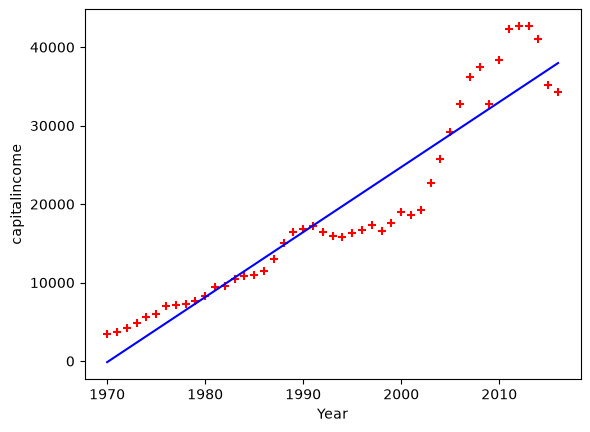

In [ ]:
%matplotlib inline
plt.xlabel("Year")
plt.ylabel("capitalincome")
plt.scatter(df.Year, df.capitalincome, color="red", marker="+")
plt.plot(df.Year, reg.predict(df[['Year']]), color="blue")
plt.show()

In [ ]:
reg.predict([[2010]])

c:\Users\abdul\Documents\BIA\bia_py_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([33004.04334219])

In [4]:
import pandas as pd
import numpy as np

In [5]:
df=pd.read_csv(r"C:\Users\abdul\Documents\BIA\ML\Dataset\Housing.csv")

In [23]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [24]:
df["prefarea"].unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [25]:
df["prefarea"].nunique()

2

In [26]:
df["prefarea"].value_counts()

prefarea
no     417
yes    128
Name: count, dtype: int64

In [27]:
df['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [8]:
TARGET="price"

In [29]:
cat_cols=df.select_dtypes(include="str").columns.tolist()
print(cat_cols)

['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [30]:
cat_cols=df.select_dtypes(include="str").columns.tolist()
num_cols=df.select_dtypes(include=np.number).columns.drop(TARGET).tolist()
print("Categorical:",cat_cols)
print("Numerical:",num_cols)
#streamlit

Categorical: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Numerical: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


In [31]:
for col in num_cols:
    df[col]=df[col].fillna(df[col].mean())
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])
print("missing after imputation:",df.isna().sum())

missing after imputation: price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit_transform(df["furnishingstatus"])

array([0, 0, 1, 0, 0, 1, 1, 2, 0, 2, 0, 1, 1, 0, 1, 1, 2, 0, 0, 1, 1, 2,
       0, 0, 0, 0, 1, 1, 2, 1, 2, 1, 0, 2, 0, 0, 0, 0, 2, 1, 0, 0, 2, 1,
       0, 1, 0, 0, 2, 1, 2, 2, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 2, 0, 0, 1, 2, 2, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 2, 1,
       2, 0, 1, 0, 0, 1, 1, 1, 0, 1, 2, 2, 2, 2, 1, 0, 0, 2, 1, 2, 1, 1,
       1, 2, 0, 0, 0, 1, 2, 0, 0, 1, 0, 1, 1, 0, 0, 1, 2, 2, 0, 1, 2, 1,
       1, 2, 1, 2, 2, 1, 1, 0, 2, 1, 1, 2, 0, 0, 1, 1, 1, 1, 2, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 2, 2, 1, 0, 1, 1, 1, 2, 2, 2, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 2, 0, 1, 2, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 2, 2, 1, 0, 1, 2,
       1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 2, 1, 2, 1, 0, 1, 1, 1, 0, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 2, 0, 2, 0, 0, 1,
       0, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 0, 1,

In [33]:
pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    dtype=int
)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,1,0,0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,1,0,0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,0,1,0
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,1,0,0
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,0,0,1
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,0,1,0
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,0,0,1
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,1,0,0


## custom approach

In [ ]:
yes_no_cols =["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]
for col in yes_no_cols:
    df[col]=df[col].map({"yes":1,"no":0})
df["furnishingstatus"]=df["furnishingstatus"].map({
    "unfurnished":1,
    "semi-furnished":2,
    "furnished":3,
})
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,3
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,3
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,3
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,3


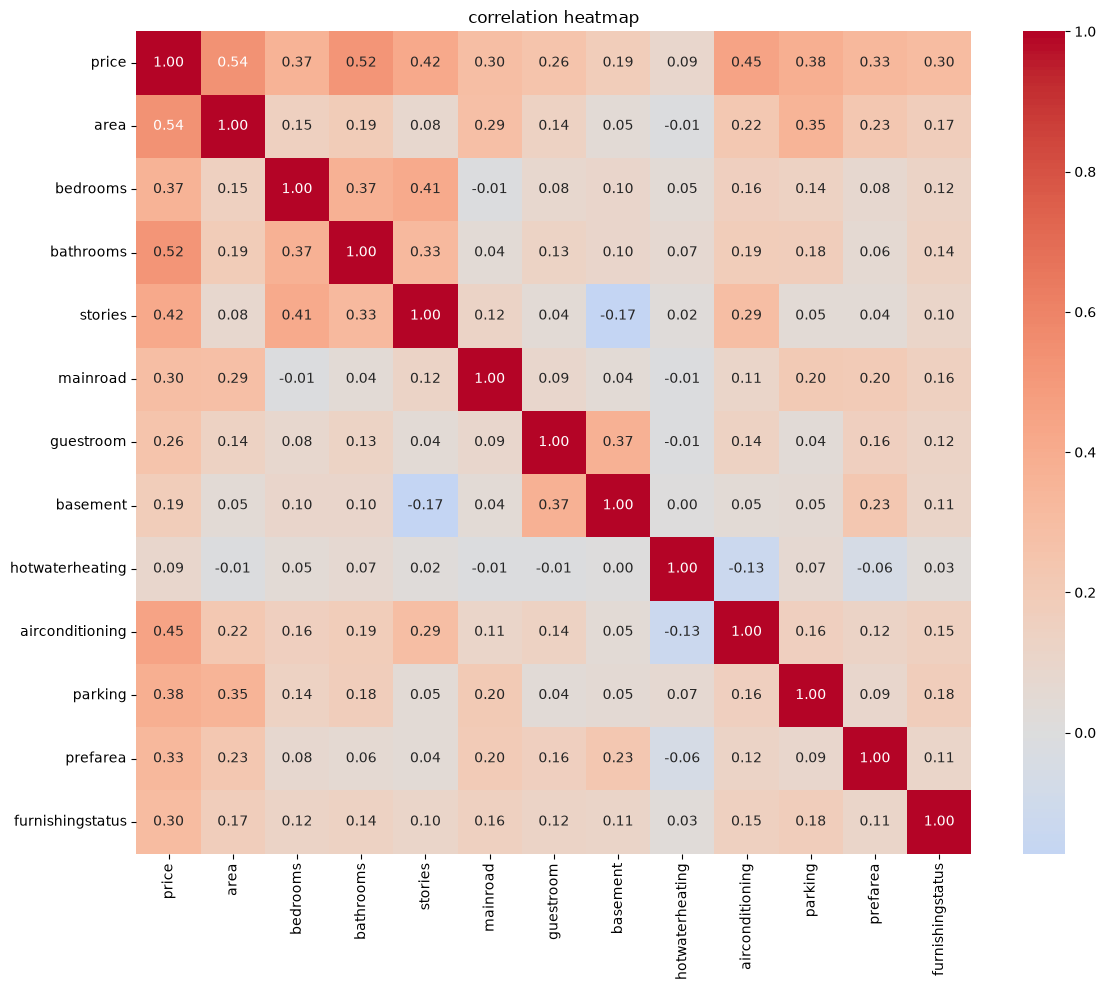

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("correlation heatmap");plt.tight_layout();plt.show()


### Train & Test

In [17]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=[TARGET])
y=df[TARGET]
X_train,X_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42)
print("Train:",X_train.shape,"Test:",X_test.shape)

Train: (436, 12) Test: (109, 12)


In [18]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='str')
Categorical: Index([], dtype='str')


## Feature Scaling - Normalaization & Standardization

In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_train_scaled=pd.DataFrame(X_train_scaled,columns=x.columns,index=X_train.index)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=x.columns,index=X_test.index)
X_train_scaled.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,0.384168,0.055271,1.539173,2.587644,0.407155,-0.466773,-0.746420,-0.230521,1.501243,0.367957,-0.552620,1.409401
93,0.929181,0.055271,1.539173,-0.912499,0.407155,-0.466773,1.339728,-0.230521,1.501243,2.709987,-0.552620,0.079317
335,-0.607755,-1.283514,-0.557950,-0.912499,0.407155,-0.466773,1.339728,-0.230521,1.501243,1.538972,-0.552620,1.409401
412,-1.155492,0.055271,-0.557950,0.254215,0.407155,-0.466773,1.339728,-0.230521,-0.666115,-0.803059,1.809561,-1.250768
471,-0.637730,0.055271,-0.557950,0.254215,0.407155,-0.466773,-0.746420,-0.230521,-0.666115,-0.803059,-0.552620,-1.250768


### Model Building

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
 
model = LinearRegression()
 
model.fit(X_train_scaled, y_train)
pred = model.predict(X_test_scaled)
print(f"  R2  : {r2_score(y_test, pred):.3f}")
print(f"  MAE : {mean_absolute_error(y_test, pred):,.0f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, pred)):,.0f}\n")
 

  R2  : 0.649
  MAE : 979,680
  RMSE: 1,331,071



In [34]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [ ]:
model.coef_9

array([519288.13010471,  58690.91849754, 523153.38284253, 348177.1136099 ,
       128115.92797751,  89357.64620755, 188462.04856579, 150570.02827934,
       362446.18646599, 192786.98589143, 266661.04914928, 158183.27016874])

In [28]:
model.intercept_

np.float64(4706527.385321101)